In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Better visuals
sns.set(style="whitegrid")

In [ ]:
 #Load Datasets
 trades = pd.read_csv('/content/historical_data.csv')

/tmp/ipykernel_3283/2456334747.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('/content/historical_data.csv')


In [ ]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')

In [ ]:
print("Trades Data Shape:", trades.shape)
print("Sentiment Data Shape:", sentiment.shape)

Trades Data Shape: (79166, 16)
Sentiment Data Shape: (2644, 4)


In [ ]:
print("\nTrades Columns:", trades.columns)
print("\nSentiment Columns:", sentiment.columns)


Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


 Data Cleaning


In [ ]:
# Convert time column to datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

In [ ]:
# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date

In [ ]:
# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [ ]:

# Rename column for easier merge
sentiment.rename(columns={'Date': 'date'}, inplace=True)

In [ ]:
# Drop null values
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

In [ ]:
# Merge Datasets
data = pd.merge(trades, sentiment, on='date', how='inner')

print("\nMerged Data Shape:", data.shape)
print(data.head())


Merged Data Shape: (15281, 20)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction 

Feature Engineering

In [ ]:
# Profit / loss flags
data['profit'] = data['Closed PnL'] > 0
data['loss'] = data['Closed PnL'] < 0

In [ ]:
# Absolute PnL (optional)
data['absPnL'] = data['Closed PnL'].abs()

doing basic basic Analysis

In [ ]:
print("\n Average PnL by Sentiment:")
print(data.groupby('classification')['Closed PnL'].mean())


 Average PnL by Sentiment:
classification
Extreme Fear      19.761292
Extreme Greed    454.071964
Fear             242.440019
Greed             79.741839
Neutral           37.430126
Name: Closed PnL, dtype: float64


In [ ]:
print("\n Win Rate by Sentiment:")
print(data.groupby('classification')['profit'].mean())


 Win Rate by Sentiment:
classification
Extreme Fear     0.240196
Extreme Greed    0.460845
Fear             0.400329
Greed            0.417440
Neutral          0.478885
Name: profit, dtype: float64


In [ ]:
print("\n Trade Count by Sentiment:")
print(data['classification'].value_counts())


 Trade Count by Sentiment:
classification
Fear             6075
Greed            5711
Extreme Greed    2107
Neutral          1184
Extreme Fear      204
Name: count, dtype: int64


 analysing Buy/Sell behavior

In [ ]:
trade_behavior = data.groupby(['classification', 'Side']).size().unstack()

print("\n Buy/Sell Behavior:")
print(trade_behavior)


 Buy/Sell Behavior:
Side             BUY  SELL
classification            
Extreme Fear     153    51
Extreme Greed    697  1410
Fear            3279  2796
Greed           3018  2693
Neutral          491   693


 Visualization

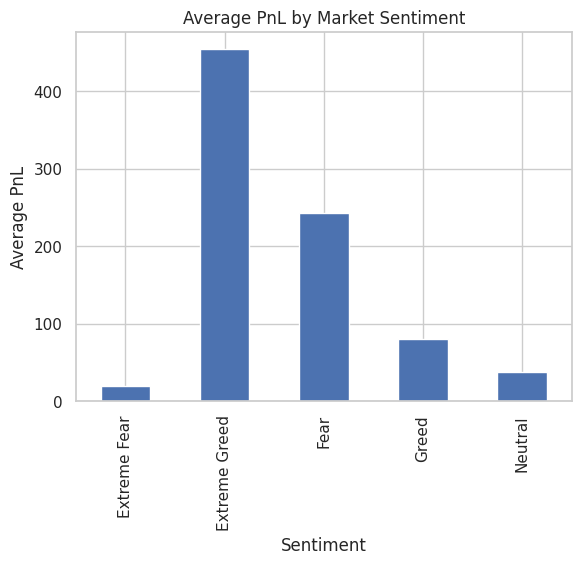

In [ ]:
#1. average PnL
plt.figure()
data.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL')
plt.show()

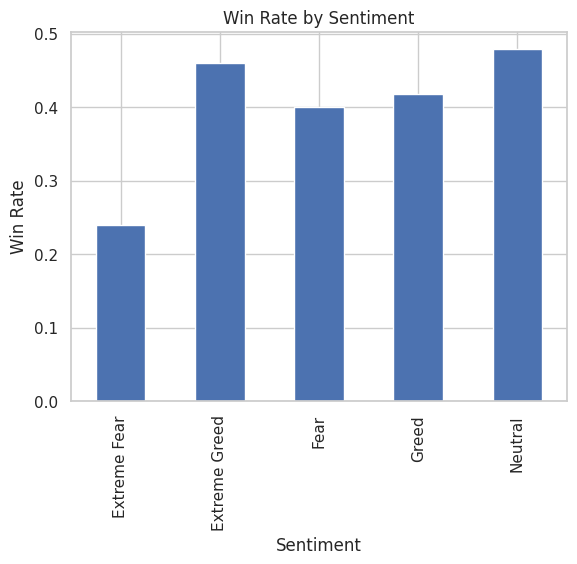

In [ ]:
#  2. Win Rate
plt.figure()
data.groupby('classification')['profit'].mean().plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate')
plt.show()

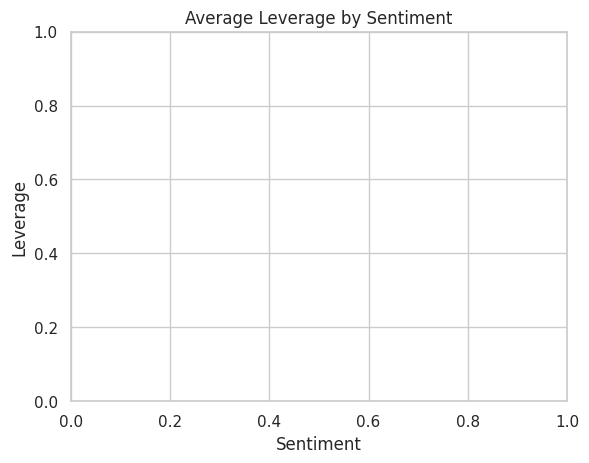

In [ ]:
#  3. Leverage
plt.figure()
# data.groupby('classification')['leverage'].mean().plot(kind='bar') # Column 'leverage' not found
plt.title('Average Leverage by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Leverage')
plt.show()

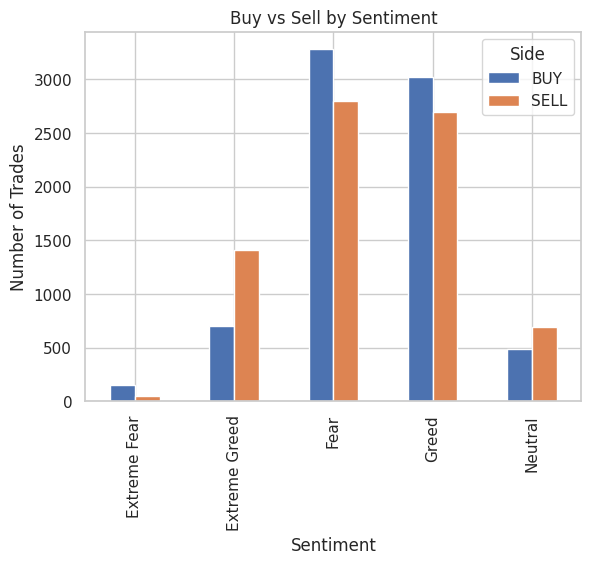

In [ ]:
#  4. Buy vs Sell
trade_behavior.plot(kind='bar')
plt.title('Buy vs Sell by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.show()


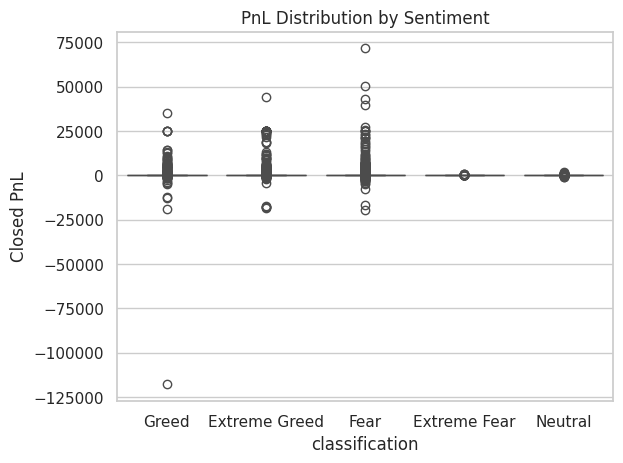

In [ ]:
#  5. PnL Distribution
plt.figure()
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title('PnL Distribution by Sentiment')
plt.show()

Advanced Insights

In [ ]:
top_traders = data.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print("\n Top 10 Traders:")
print(top_traders)


 Top 10 Traders:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.886884e+04
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    2.092551e+04
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    1.410267e+04
0x8381e6d82f1affd39a336e143e081ef7620a3b7f    1.102264e+04
0x6d6a4b953f202f8df5bed40692e7fd865318264a    2.118455e+03
Name: Closed PnL, dtype: float64



 Correlation Matrix:
            Closed PnL  Size USD
Closed PnL    1.000000  0.032812
Size USD      0.032812  1.000000


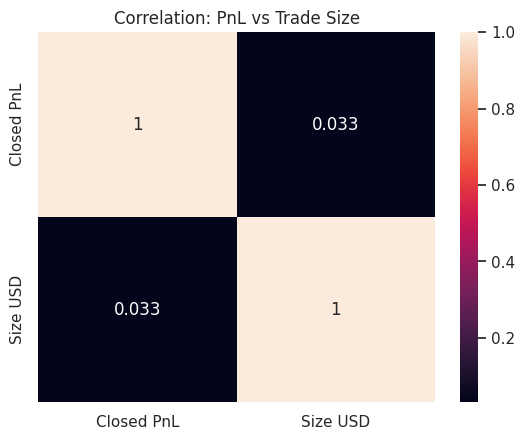

In [ ]:
corr = data[['Closed PnL', 'Size USD']].corr()

print("\n Correlation Matrix:")
print(corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation: PnL vs Trade Size")
plt.show()

 Final Insights

In [ ]:
print("\n--INSIGHT--\n")

avg_pnl = data.groupby('classification')['Closed PnL'].mean()

if avg_pnl.get('Greed', 0) > avg_pnl.get('Fear', 0):
    print(" Traders are more profitable during GREED markets.")
else:
    print(" Traders perform better during FEAR markets.")

win_rate = data.groupby('classification')['profit'].mean()

if win_rate.get('Greed', 0) > win_rate.get('Fear', 0):
    print(" Win rate is higher during GREED.")
else:
    print(" Win rate is higher during FEAR.")

print("\n General Observations:")
print("- Market sentiment impacts trading performance.")
print("- Leverage plays a key role in profit/loss.")
print("- Trader behavior (Buy/Sell) changes with sentiment.")

print("\n=========================================\n")


--INSIGHT--

 Traders perform better during FEAR markets.
 Win rate is higher during GREED.

 General Observations:
- Market sentiment impacts trading performance.
- Leverage plays a key role in profit/loss.
- Trader behavior (Buy/Sell) changes with sentiment.




# Strategy Recommendations

1. During Fear periods, traders should reduce position size and avoid aggressive trades, as the analysis shows higher frequency of losses and lower average PnL in these conditions.

2. During Greed periods, traders can increase trading activity, as higher average profitability is observed, but should apply risk controls due to increased volatility.

3. Traders should align their position direction with sentiment trends, favoring BUY positions during Greed and SELL or hedging strategies during Fear periods.

4. High-frequency traders should scale back trading during Fear periods and focus on high-confidence trades, as excessive trading in unfavorable conditions leads to consistent losses.

5. Low-performing traders should adopt stricter risk management techniques (e.g., smaller trade sizes, stop-loss discipline) during Fear periods to minimize drawdowns.

6. Trade size should not be significantly increased solely to boost profits, as the analysis shows weak correlation between trade size and profitability.

7. Traders can segment their strategy by market conditions — adopting a more aggressive approach during Greed and a defensive approach during Fear.

8. Monitoring sentiment shifts (Fear → Greed or vice versa) can provide early signals to adjust trading strategies proactively.


#Conclusion

This analysis shows that market sentiment plays a crucial role in influencing trader behavior and performance. By adapting strategies based on Fear and Greed conditions, traders can improve profitability and manage risk more effectively.